# A Notebook Explores the Dataset

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os

PROJECT_ROOT = Path().resolve().parent
os.chdir(PROJECT_ROOT)

print("Working dir set to:", os.getcwd())

Working dir set to: /Users/rx/Documents/Self-Development/github-project/data-center-siting-analysis


## Import Dataset

In [2]:
df = pd.read_csv("data_revealed/03_tables/county_final_table_clean.csv")
print(df.info())
print(df.describe())
print(df.columns)
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.isnull().sum()/len(df))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3149 entries, 0 to 3148
Data columns (total 41 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   county_fips                         3149 non-null   object 
 1   epg_natural_gas                     3141 non-null   float64
 2   clean_energy_jobs                   3141 non-null   float64
 3   grid_infrastructure_jobs            3141 non-null   float64
 4   any_tech_1000_100_coverage          3141 non-null   float64
 5   any_tech_100_20_coverage            3141 non-null   float64
 6   cable_fiber_100_20_coverage         3141 non-null   float64
 7   fiber_100_20_coverage               3141 non-null   float64
 8   fiber_availability                  3141 non-null   float64
 9   high_speed_wired_coverage           3141 non-null   float64
 10  land_value_1_4_acre_standardized    2267 non-null   float64
 11  commercial_price                    3104 no

## Missingness map

Each column is a feature (excluding county_fips, state, and county name). Each row is an observation. Cell color: missing (e.g. red) vs present (e.g. white).

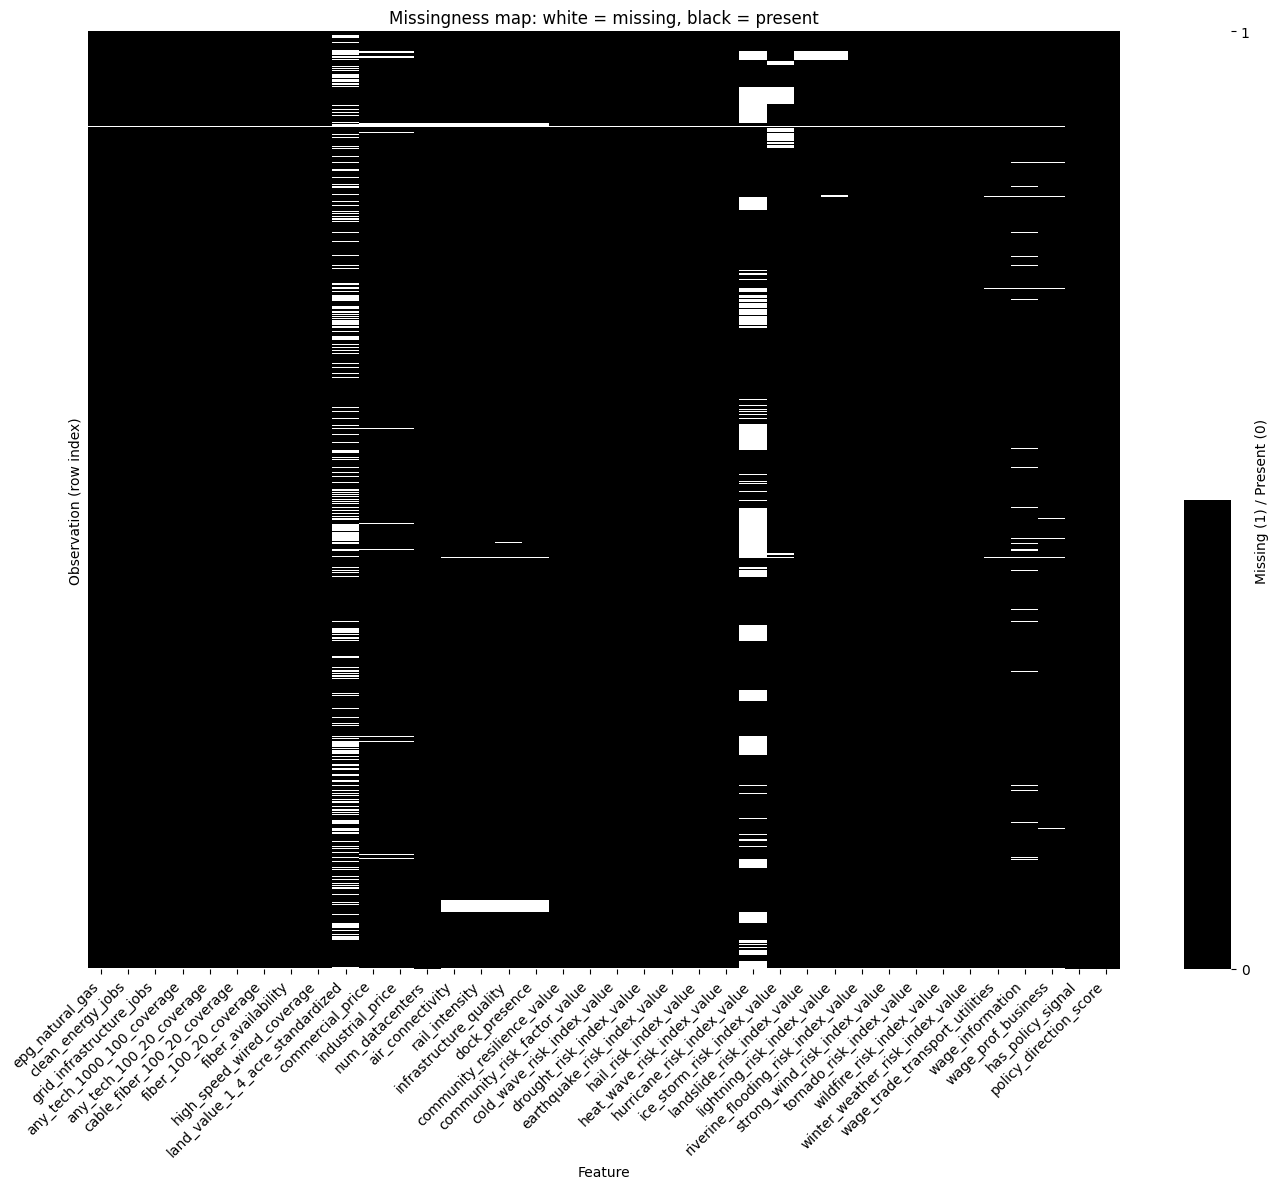

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Features only: exclude county_fips, state, county (name)
exclude = {"county_fips", "state", "county"}
feature_cols = [c for c in df.columns if c not in exclude]
missing = df[feature_cols].isna().astype(int)  # 1 = missing, 0 = present

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    missing,
    cmap=["black", "white"],  # 0 = black (present), 1 = white (missing)
    cbar_kws={"label": "Missing (1) / Present (0)", "ticks": [0, 1]},
    yticklabels=False,
    xticklabels=feature_cols,
    ax=ax,
)
ax.set_xlabel("Feature")
ax.set_ylabel("Observation (row index)")
ax.set_title("Missingness map: white = missing, black = present")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Missingness Summary

A heatmap is useful for spotting row-wise patterns, but a sorted bar chart makes the exact missingness rate per feature easier to read.

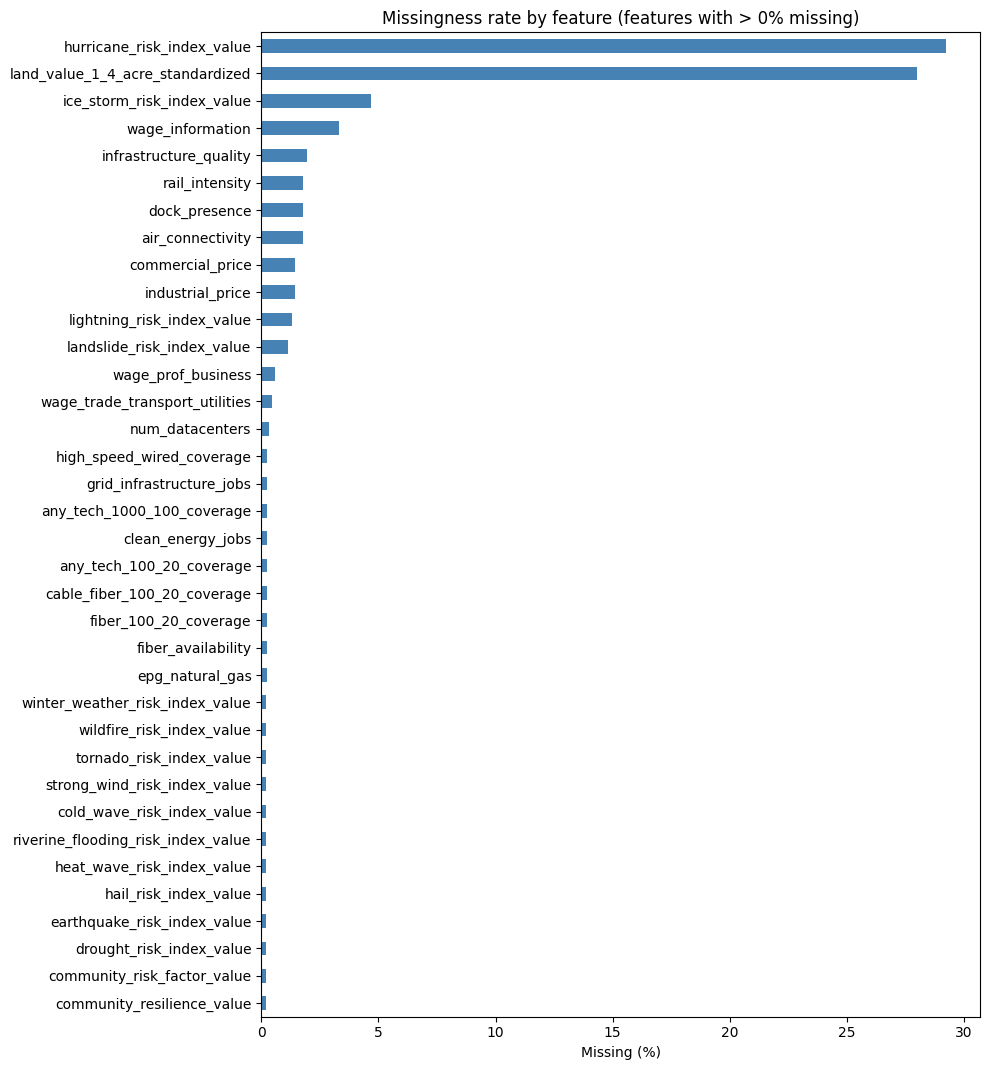

hurricane_risk_index_value            29.22
land_value_1_4_acre_standardized      28.01
ice_storm_risk_index_value             4.67
wage_information                       3.30
infrastructure_quality                 1.94
rail_intensity                         1.78
dock_presence                          1.78
air_connectivity                       1.78
commercial_price                       1.43
industrial_price                       1.43
lightning_risk_index_value             1.30
landslide_risk_index_value             1.14
wage_prof_business                     0.60
wage_trade_transport_utilities         0.44
num_datacenters                        0.35
high_speed_wired_coverage              0.25
grid_infrastructure_jobs               0.25
any_tech_1000_100_coverage             0.25
clean_energy_jobs                      0.25
any_tech_100_20_coverage               0.25
cable_fiber_100_20_coverage            0.25
fiber_100_20_coverage                  0.25
fiber_availability              

In [4]:
missing_pct = (df[feature_cols].isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(missing_pct))))
missing_pct.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Missing (%)")
ax.set_title("Missingness rate by feature (features with > 0% missing)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(missing_pct.round(2))

**Observations**

- `hurricane_risk_index_value` (~29%) and `land_value_1_4_acre_standardized` (~28%) have by far the highest missingness. Both are plausibly *structurally* missing (e.g., the hurricane risk index isn't computed for inland counties), not missing-at-random — these should be imputed with 0 / a "not applicable" flag rather than dropped.
- Most other features have under 2% missingness, consistent with a small number of counties having incomplete source records across the board.
- `has_policy_signal` and `policy_direction_score` have 0% missingness by construction (absence of evidence is already encoded as 0).

## Structural Integrity Checks

Checks for duplicate/placeholder identifiers and the geographic coverage of the table.

In [5]:
print("Rows:", len(df), "| Unique county_fips:", df["county_fips"].nunique())
print("Duplicated county_fips values:", df["county_fips"].duplicated().sum())
print()

dup_mask = df["county_fips"].duplicated(keep=False)
print("Rows sharing a duplicated/placeholder county_fips:")
print(df.loc[dup_mask, ["county_fips", "state", "county"]])
print()

print("States/territories represented:", df["state"].nunique())
print(sorted(df["state"].unique()))

Rows: 3149 | Unique county_fips: 3147
Duplicated county_fips values: 2

Rows sharing a duplicated/placeholder county_fips:
    county_fips        state                county
317       0<NA>  Connecticut     Middletown County
318       0<NA>      Georgia  Athens-Clarke County
319       0<NA>     Virginia         Loudon County

States/territories represented: 52
['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virgin Islands', 'Virginia', 'Washington', 'West Virgini

**Observations**

- Three rows (Middletown County CT, Athens-Clarke County GA, Loudoun County VA — all independent cities / consolidated city-county governments) share a placeholder `county_fips` value. Their feature columns are populated, so they're usable for modeling, but `county_fips` cannot be relied on as a join key for these rows. Worth flagging for the reference-table pipeline.
- 52 states/territories are represented, including the District of Columbia and the Virgin Islands — consistent with the underlying source tables.

## Target Diagnostics: `num_datacenters`

`num_datacenters` is the project's target variable — an estimated (fractional) count of data centers per county, built by allocating ZIP-level counts to counties via the business-ratio crosswalk. We check its distribution, zero-inflation, and skewness to inform the modeling strategy.

count    3138.000000
mean        1.387827
std         8.461801
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       304.006814
Name: num_datacenters, dtype: float64

Missing: 11 (0.35%)
Exact zeros: 2371 (75.29%)
Skewness (raw): 19.81
Skewness (log1p): 3.10


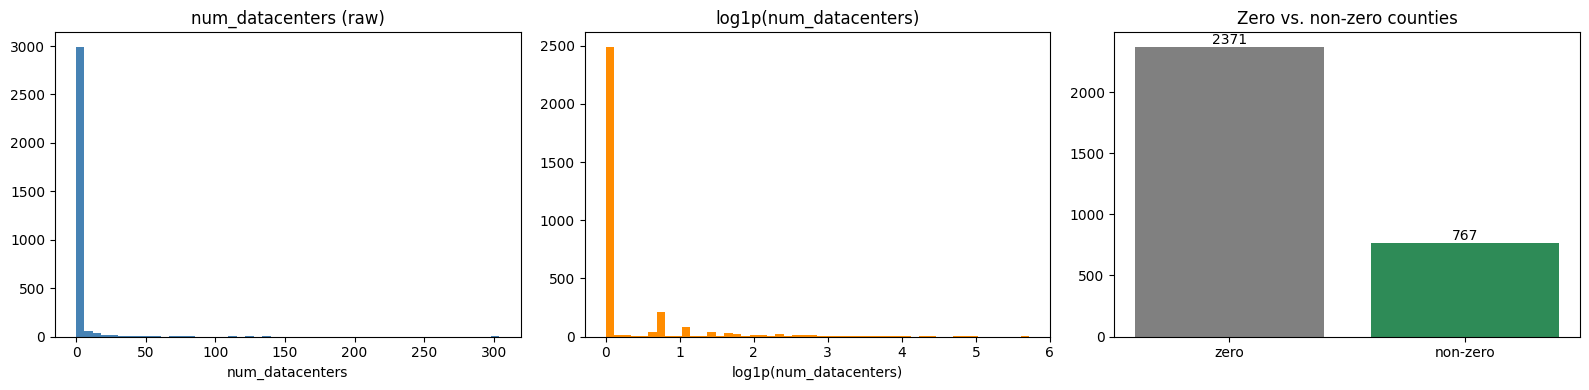

In [6]:
target = "num_datacenters"
y = df[target]

print(y.describe())
print()
print(f"Missing: {y.isna().sum()} ({y.isna().mean():.2%})")
print(f"Exact zeros: {(y == 0).sum()} ({(y == 0).mean():.2%})")
print(f"Skewness (raw): {y.skew():.2f}")
print(f"Skewness (log1p): {np.log1p(y.dropna()).skew():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y.dropna(), bins=50, color="steelblue")
axes[0].set_title("num_datacenters (raw)")
axes[0].set_xlabel("num_datacenters")

axes[1].hist(np.log1p(y.dropna()), bins=50, color="darkorange")
axes[1].set_title("log1p(num_datacenters)")
axes[1].set_xlabel("log1p(num_datacenters)")

zero_share = pd.Series({"zero": (y == 0).sum(), "non-zero": (y > 0).sum()})
axes[2].bar(zero_share.index, zero_share.values, color=["gray", "seagreen"])
axes[2].set_title("Zero vs. non-zero counties")
for i, v in enumerate(zero_share.values):
    axes[2].text(i, v + 20, str(v), ha="center")

plt.tight_layout()
plt.show()

In [7]:
top_states = df.groupby("state")[target].sum().sort_values(ascending=False).head(10)
print("Top 10 states by total estimated num_datacenters:")
print(top_states.round(1))

Top 10 states by total estimated num_datacenters:
state
Virginia      674.0
Texas         464.0
California    278.0
Illinois      247.0
Georgia       224.0
Ohio          217.0
Arizona       163.0
New York      143.0
Oregon        138.0
Washington    133.0
Name: num_datacenters, dtype: float64


**Observations**

- About 75% of counties have an estimated `num_datacenters` of exactly 0 — this is a **zero-inflated** target, not a simple continuous variable.
- Among counties with at least one data center, the distribution is extremely right-skewed (median ≈ 1, max > 300 — Loudoun County, VA, the largest U.S. data center market, is the clear outlier).
- Raw skewness (~20) drops substantially after `log1p`, but the mass at zero remains. This points toward either:
  1. A **two-part / hurdle model** — classify "has any data center presence" (binary), then model the positive count separately, or
  2. A **Tweedie/Poisson-family regressor** (e.g., XGBoost/LightGBM with a `tweedie` objective), which natively handles zero-inflated, right-skewed counts.
- The top-state ranking lines up with well-known data center hubs (Virginia, Texas, California, Illinois) — a useful sanity check that the target was constructed correctly.

## Feature Distribution & Transform Needs

Histograms for all numeric features (excluding identifiers and the target), to spot skew, near-constant columns, and candidates for log transforms / standardization before modeling.

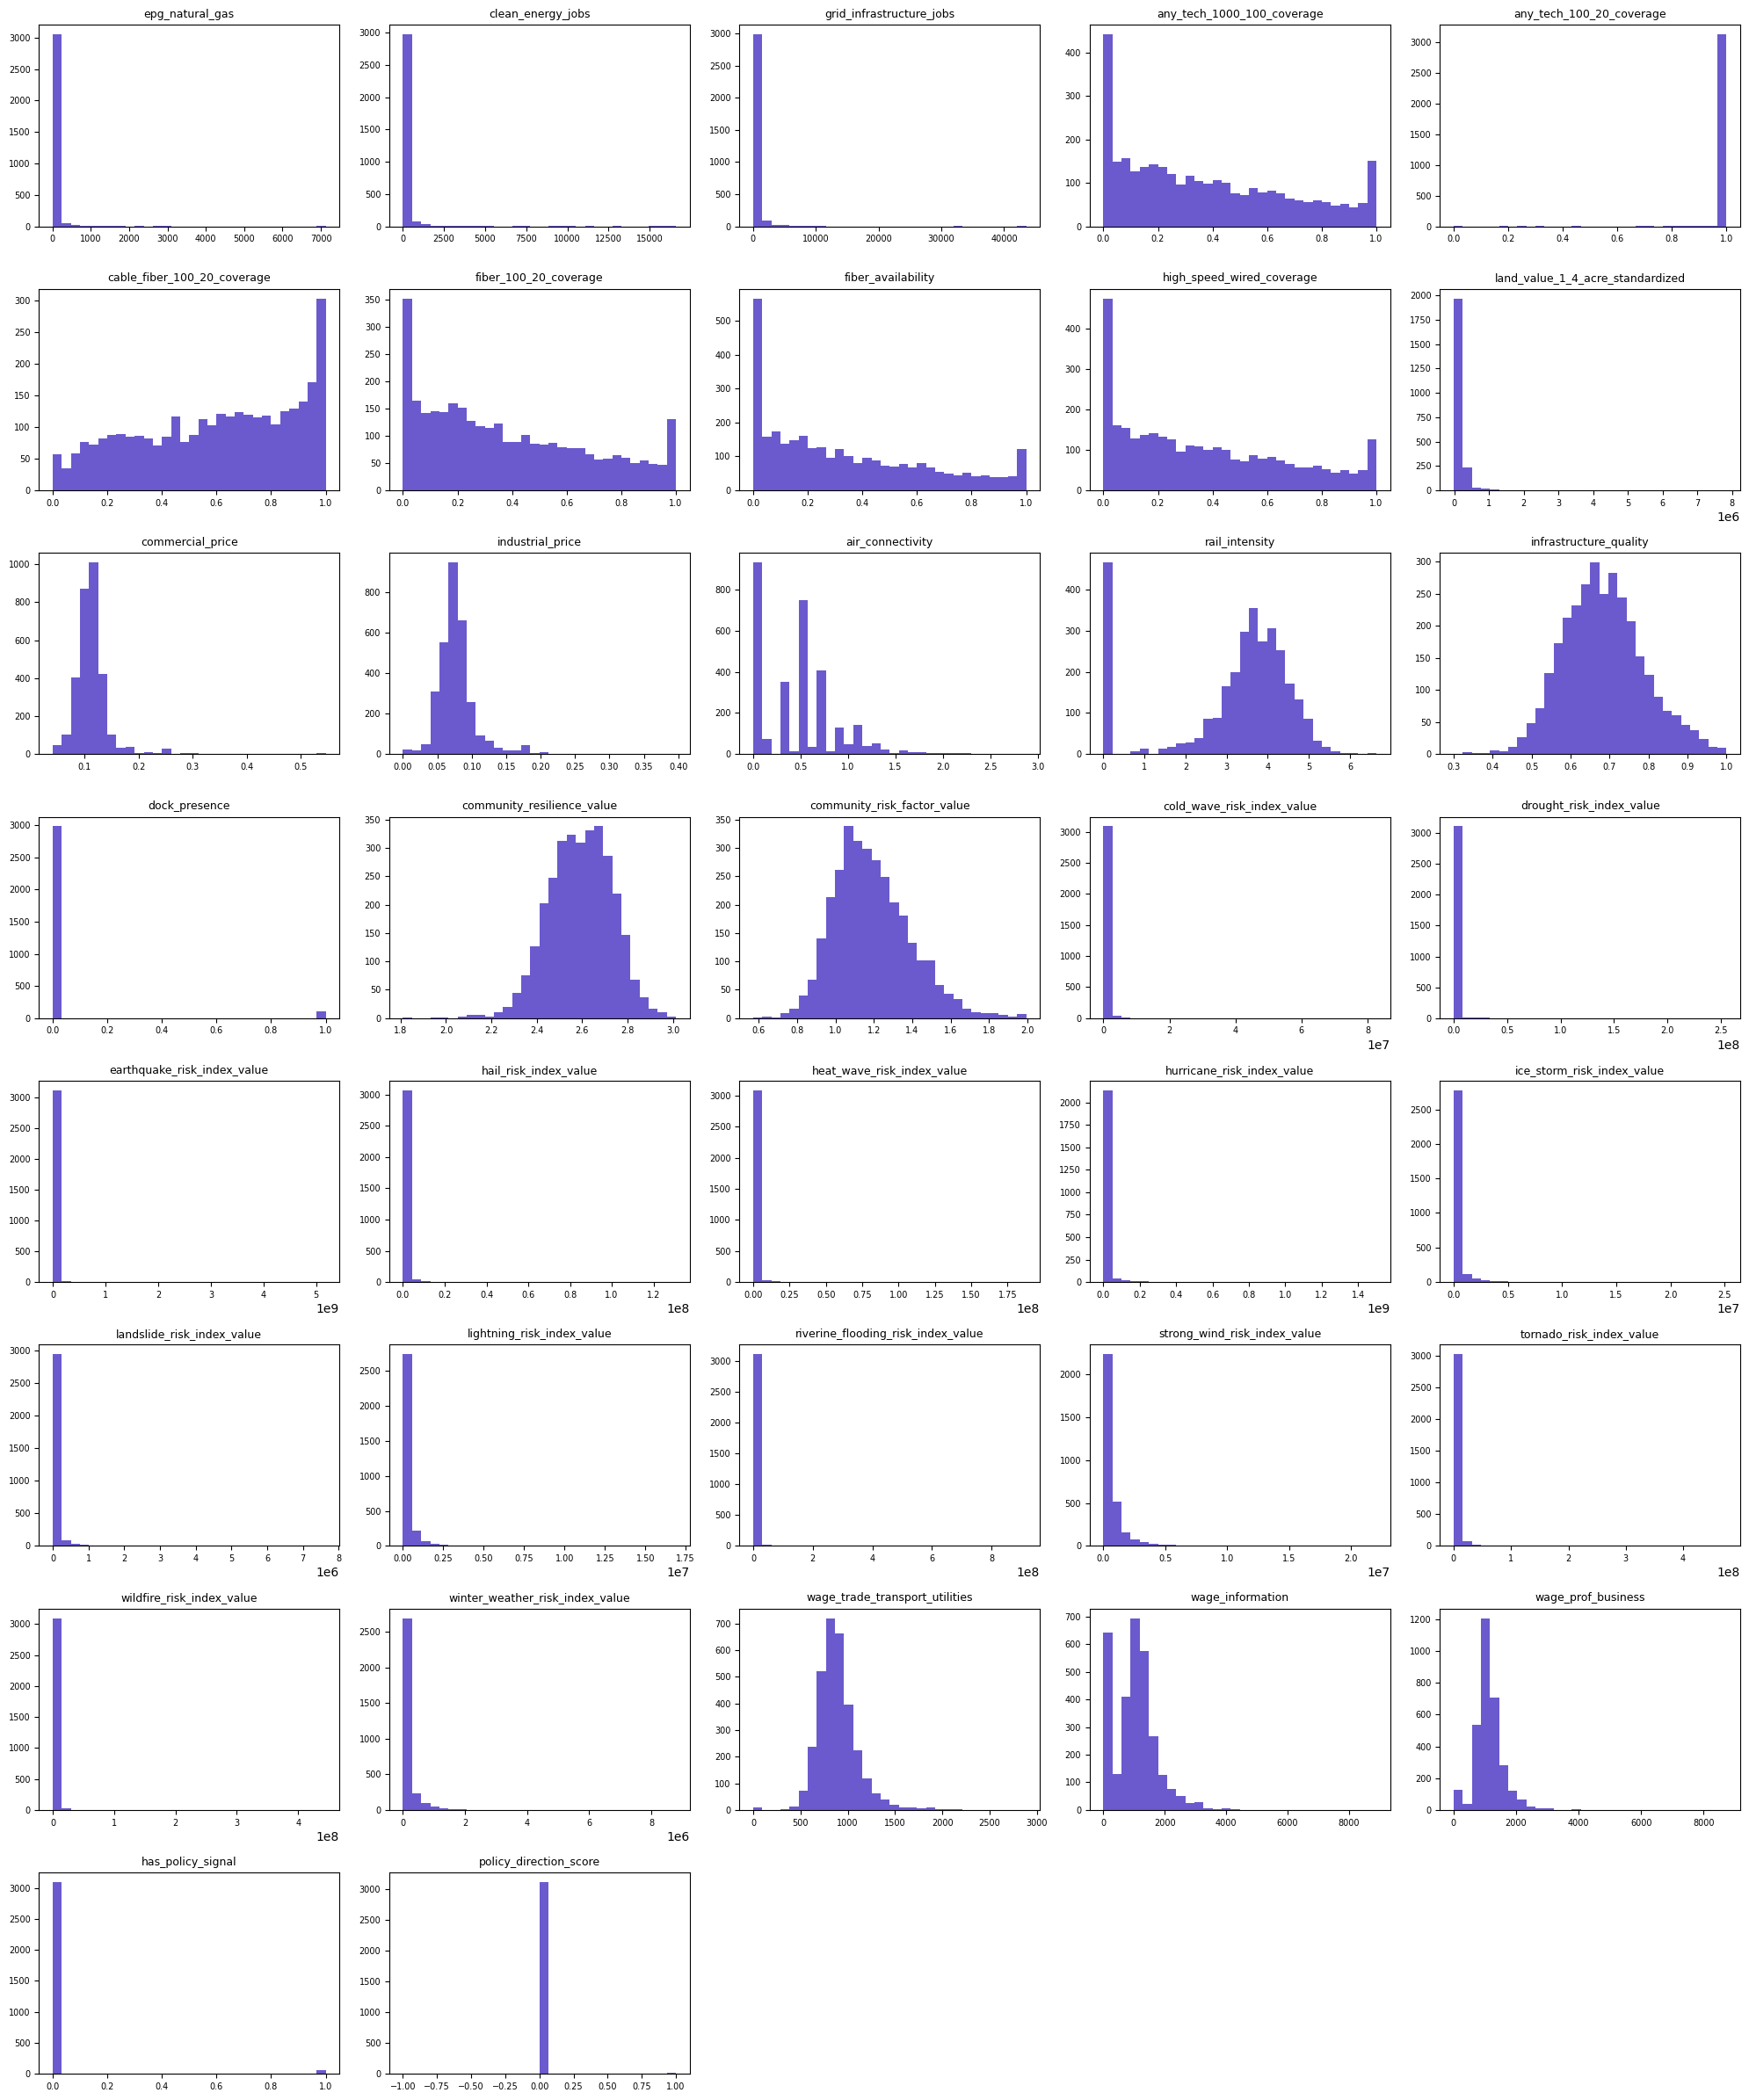

In [8]:
exclude_for_dist = {"county_fips", "state", "county", "num_datacenters"}
hist_cols = [c for c in df.columns if c not in exclude_for_dist]

n_cols = 5
n_rows = -(-len(hist_cols) // n_cols)  # ceil division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, hist_cols):
    ax.hist(df[col].dropna(), bins=30, color="slateblue")
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes[len(hist_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
skew = df[hist_cols].skew().sort_values(key=abs, ascending=False)
print("Skewness by feature (sorted by magnitude):")
print(skew.round(2))

high_skew = skew[skew.abs() > 1]
print(f"\n{len(high_skew)} features with |skew| > 1 -- candidates for log transform before modeling:")
print(high_skew.index.tolist())

Skewness by feature (sorted by magnitude):
cold_wave_risk_index_value            39.54
earthquake_risk_index_value           36.52
riverine_flooding_risk_index_value    36.29
wildfire_risk_index_value             31.25
drought_risk_index_value              25.48
any_tech_100_20_coverage             -21.41
heat_wave_risk_index_value            20.97
tornado_risk_index_value              20.49
grid_infrastructure_jobs              19.54
epg_natural_gas                       18.36
hail_risk_index_value                 17.92
land_value_1_4_acre_standardized      16.62
hurricane_risk_index_value            15.10
landslide_risk_index_value            14.04
ice_storm_risk_index_value            12.44
clean_energy_jobs                     12.29
lightning_risk_index_value            10.44
winter_weather_risk_index_value        8.28
has_policy_signal                      7.37
strong_wind_risk_index_value           6.51
policy_direction_score                 6.40
dock_presence                    

**Observations**

- Most of the **NRI hazard risk indices** (cold wave, earthquake, riverine flooding, wildfire, drought, etc.) are extremely right-skewed (|skew| > 10) — near-zero for most counties with a long tail of high-risk counties. `log1p` is appropriate.
- `grid_infrastructure_jobs`, `clean_energy_jobs`, and `epg_natural_gas` are also heavily skewed, consistent with employment concentrated in a small number of energy-producing counties.
- `any_tech_100_20_coverage` is essentially **constant** (mean ≈ 0.998, std ≈ 0.04) — almost every county already has ≥100/20 Mbps coverage somewhere. This feature carries little signal and is a candidate to drop in favor of the stricter `any_tech_1000_100_coverage`.
- Coverage-rate features (`fiber_*`, `cable_fiber_*`, `high_speed_wired_coverage`) are bounded in [0, 1] and only mildly skewed — standardization without a log transform is sufficient.
- Wage and price/value features (`wage_*`, `commercial_price`, `industrial_price`, `land_value_*`) are moderately right-skewed — log transform recommended.

## Risk Block Correlation Analysis

The National Risk Index contributes 14 hazard-specific risk indices plus two summary scores (`community_resilience_value`, `community_risk_factor_value`). Many of these are likely correlated (e.g., hurricane/flooding on the coast, cold wave/winter weather inland) — we check for redundancy before modeling.

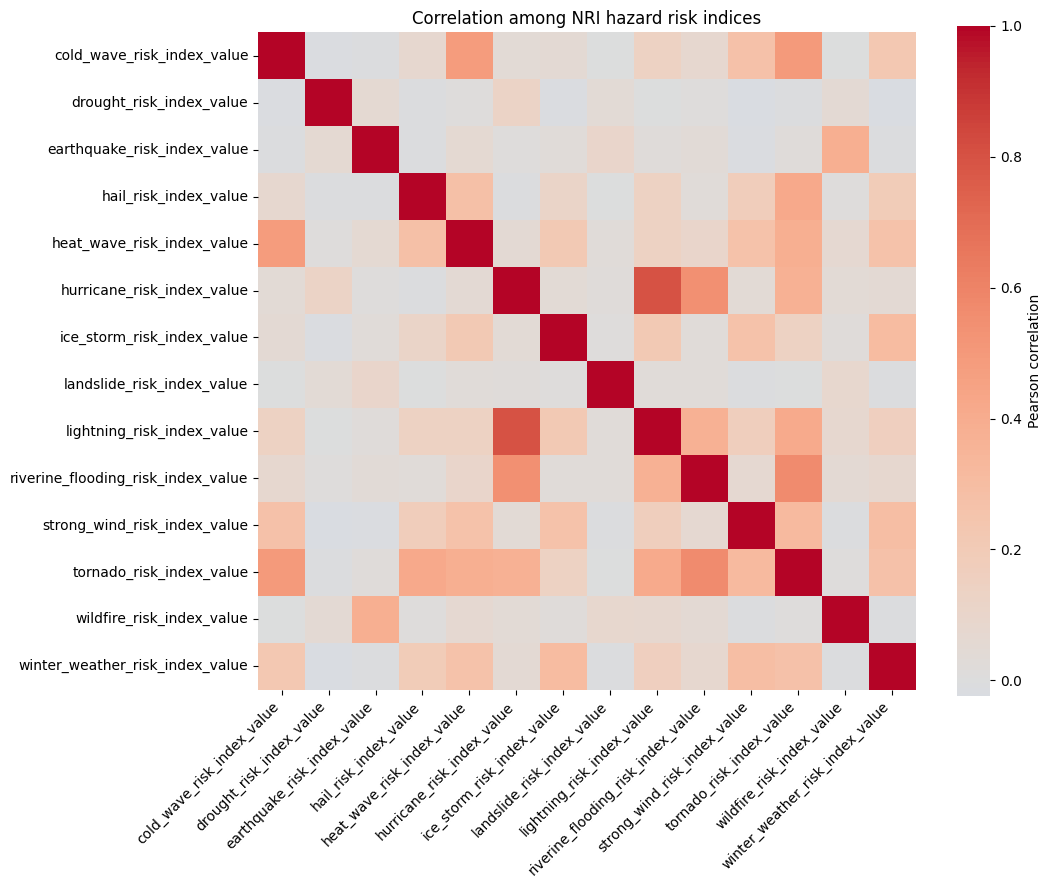

Top 10 most correlated risk index pairs:
hurricane_risk_index_value          lightning_risk_index_value            0.801948
riverine_flooding_risk_index_value  tornado_risk_index_value              0.567104
hurricane_risk_index_value          riverine_flooding_risk_index_value    0.542008
cold_wave_risk_index_value          tornado_risk_index_value              0.497934
                                    heat_wave_risk_index_value            0.484134
hail_risk_index_value               tornado_risk_index_value              0.420102
lightning_risk_index_value          tornado_risk_index_value              0.413296
earthquake_risk_index_value         wildfire_risk_index_value             0.391247
heat_wave_risk_index_value          tornado_risk_index_value              0.388906
lightning_risk_index_value          riverine_flooding_risk_index_value    0.375915
dtype: float64


In [10]:
risk_cols = [c for c in df.columns if c.endswith("risk_index_value")]

corr = df[risk_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True,
            cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Correlation among NRI hazard risk indices")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Strongest pairwise correlations (excluding self-correlation, deduplicated)
corr_pairs = corr.where(~np.eye(len(corr), dtype=bool)).unstack().dropna()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]
print("Top 10 most correlated risk index pairs:")
print(corr_pairs.abs().sort_values(ascending=False).head(10))

**Observations**

- `hurricane_risk_index_value` and `lightning_risk_index_value` are strongly correlated (r ≈ 0.80) — both driven by Gulf/Atlantic coast exposure.
- `tornado_risk_index_value` correlates moderately-to-strongly with several other hazards (cold wave, hail, heat wave, riverine flooding, lightning) — it sits at the center of a broader "severe weather corridor" cluster (Tornado Alley / Central & Southeast US).
- Most other pairs have |r| < 0.3 — the risk block is largely non-redundant. `hurricane_risk_index_value` and `lightning_risk_index_value` are the main candidates for consolidation if multicollinearity becomes an issue in linear models; for tree-based models this is less of a concern.

## Infrastructure Block Analysis

Grid, broadband, transportation, and cost features describe the physical readiness of a county for large-scale compute. We check for multicollinearity and near-zero-variance features within this block.

Standard deviation (near-zero-variance check):
industrial_price                         0.029698
commercial_price                         0.035723
any_tech_100_20_coverage                 0.037544
infrastructure_quality                   0.103885
dock_presence                            0.184418
cable_fiber_100_20_coverage              0.288131
fiber_100_20_coverage                    0.295619
fiber_availability                       0.296499
high_speed_wired_coverage                0.298671
any_tech_1000_100_coverage               0.303410
air_connectivity                         0.440992
rail_intensity                           1.517350
epg_natural_gas                        207.790984
clean_energy_jobs                      812.221321
grid_infrastructure_jobs              1272.004357
land_value_1_4_acre_standardized    247028.979429
dtype: float64



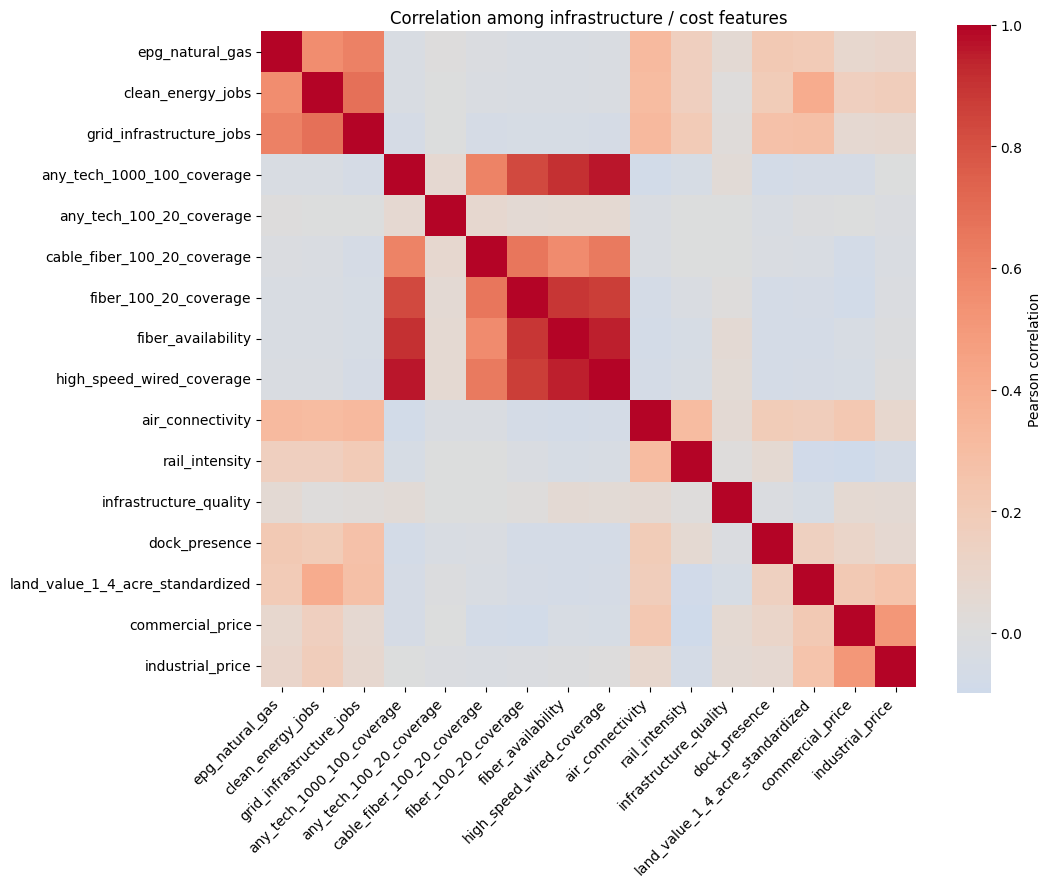

In [11]:
infra_cols = [
    "epg_natural_gas", "clean_energy_jobs", "grid_infrastructure_jobs",
    "any_tech_1000_100_coverage", "any_tech_100_20_coverage",
    "cable_fiber_100_20_coverage", "fiber_100_20_coverage",
    "fiber_availability", "high_speed_wired_coverage",
    "air_connectivity", "rail_intensity", "infrastructure_quality", "dock_presence",
    "land_value_1_4_acre_standardized", "commercial_price", "industrial_price",
]

print("Standard deviation (near-zero-variance check):")
print(df[infra_cols].std().sort_values())
print()

corr = df[infra_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Correlation among infrastructure / cost features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observations**

- `any_tech_100_20_coverage` again stands out with std ≈ 0.04 — near-zero variance, low information.
- The broadband coverage features (`any_tech_1000_100_coverage`, `cable_fiber_100_20_coverage`, `fiber_100_20_coverage`, `fiber_availability`, `high_speed_wired_coverage`) are highly inter-correlated, as expected since they're pivoted from the same underlying FCC table at different speed/technology cuts. For modeling, it's worth keeping 1-2 representative broadband features (e.g., `fiber_availability` and `any_tech_1000_100_coverage`) rather than all five, or relying on a tree-based model's robustness to collinear features.
- `clean_energy_jobs` and `grid_infrastructure_jobs` are positively correlated but not redundant — both relate to energy-sector employment but capture different infrastructure types.
- Cost features (`land_value_1_4_acre_standardized`, `commercial_price`, `industrial_price`) show low correlation with the connectivity/grid features, suggesting they capture an independent "cost" dimension.

## Policy Signal Sparsity & Effect

`has_policy_signal` / `policy_direction_score` come from the LLM-checked policy search pipeline and are extremely sparse (non-zero only for counties with an observed policy mention). We check how sparse, and whether the signal relates to the target.

has_policy_signal
0.0    0.982534
1.0    0.017466
Name: share, dtype: float64

policy_direction_score distribution among counties with a policy signal:
count    55.000000
mean      0.317424
std       0.643127
min      -1.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       1.000000
Name: policy_direction_score, dtype: float64

num_datacenters by policy signal:
                    count       mean        std  min  25%  50%       75%  \
has_policy_signal                                                          
0.0                3086.0   1.219187   6.220496  0.0  0.0  0.0  0.000000   
1.0                  52.0  11.395920  44.268959  0.0  0.0  2.0  4.700906   

                          max  
has_policy_signal              
0.0                136.050000  
1.0                304.006814  


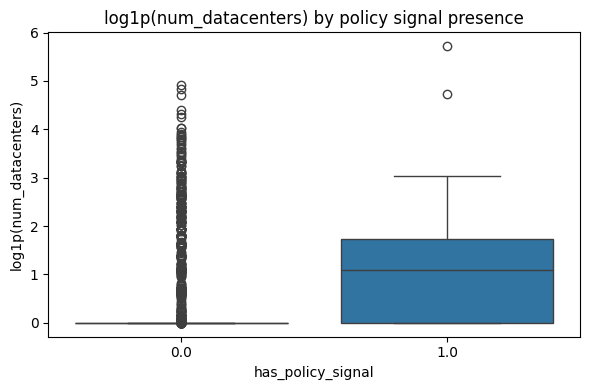

In [12]:
print(df["has_policy_signal"].value_counts(normalize=True).rename("share"))
print()

print("policy_direction_score distribution among counties with a policy signal:")
print(df.loc[df["has_policy_signal"] == 1, "policy_direction_score"].describe())
print()

print("num_datacenters by policy signal:")
print(df.groupby("has_policy_signal")[target].describe())

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="has_policy_signal", y=np.log1p(df[target]), ax=ax)
ax.set_ylabel("log1p(num_datacenters)")
ax.set_title("log1p(num_datacenters) by policy signal presence")
plt.tight_layout()
plt.show()

**Observations**

- Only 55 of 3,149 counties (~1.7%) have any observed policy signal — this feature will be near-zero in most rows, so its aggregate predictive contribution will likely be small, though potentially informative for the specific counties where it's non-zero.
- Counties with a policy signal have a noticeably higher `num_datacenters` on average, but `policy_direction_score` itself is mixed (ranges from -1 to 1). This is consistent with policy attention *following* existing data center activity (reverse causality / confounding) as much as shaping new siting decisions — worth discussing carefully in the analysis report rather than reading as a causal driver.

## Preliminary Feature–Target Signal Scan

A first pass at which features correlate (linearly) with `log1p(num_datacenters)`, to sanity-check the feature set before modeling. This is a screening tool, not a final feature-selection step — tree-based models can pick up non-linear and interaction effects that simple correlations miss.

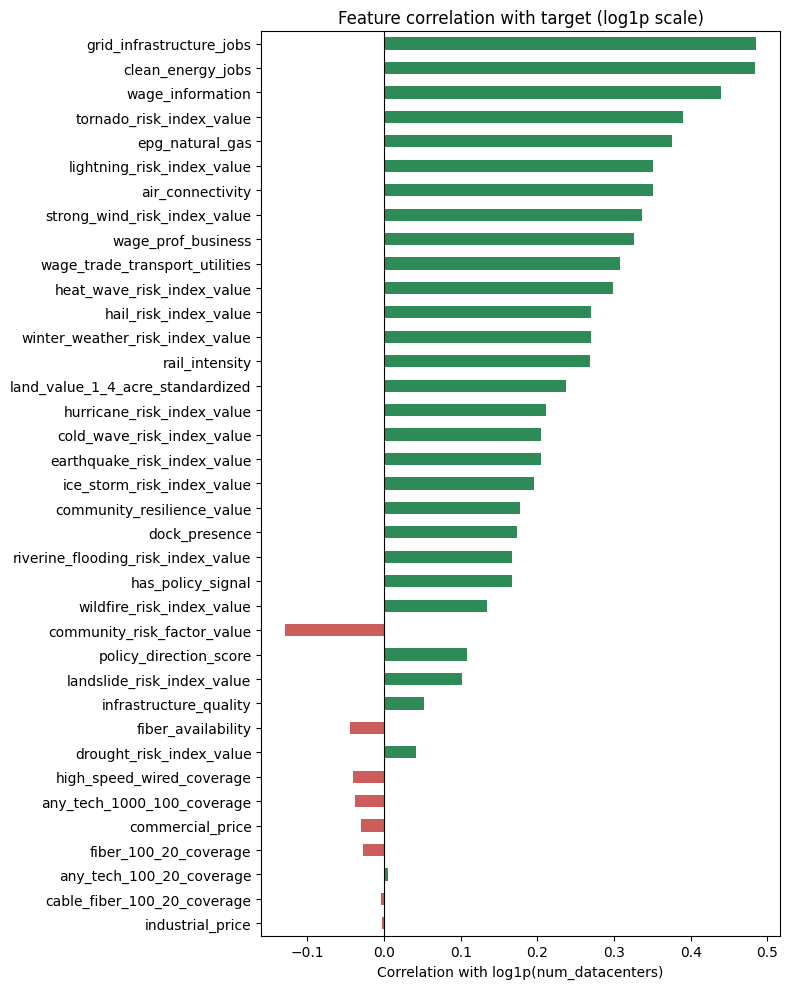

grid_infrastructure_jobs              0.486
clean_energy_jobs                     0.484
wage_information                      0.440
tornado_risk_index_value              0.390
epg_natural_gas                       0.375
lightning_risk_index_value            0.351
air_connectivity                      0.351
strong_wind_risk_index_value          0.336
wage_prof_business                    0.326
wage_trade_transport_utilities        0.308
heat_wave_risk_index_value            0.299
hail_risk_index_value                 0.270
winter_weather_risk_index_value       0.270
rail_intensity                        0.268
land_value_1_4_acre_standardized      0.237
hurricane_risk_index_value            0.211
cold_wave_risk_index_value            0.205
earthquake_risk_index_value           0.205
ice_storm_risk_index_value            0.196
community_resilience_value            0.177
dock_presence                         0.173
riverine_flooding_risk_index_value    0.167
has_policy_signal               

In [13]:
y_log = np.log1p(df[target])
num_cols = df.select_dtypes(include=[np.number]).columns.drop(target)

target_corr = df[num_cols].corrwith(y_log).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
colors = target_corr.apply(lambda v: "seagreen" if v > 0 else "indianred")
target_corr.plot(kind="barh", ax=ax, color=colors)
ax.invert_yaxis()
ax.set_xlabel("Correlation with log1p(num_datacenters)")
ax.set_title("Feature correlation with target (log1p scale)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print(target_corr.round(3))

**Observations**

- The strongest correlates are `grid_infrastructure_jobs`, `clean_energy_jobs`, `wage_information`, `epg_natural_gas`, and `air_connectivity` (all r ≈ 0.35–0.49) — consistent with the intuition that existing energy/grid/connectivity infrastructure and a skilled IT-adjacent labor market predict data center presence.
- Several **risk indices** (`tornado`, `lightning`, `strong_wind`, `heat_wave`) show positive correlation with the target. This is very likely **geographic confounding** rather than a causal "more risk → more data centers" relationship — these hazards are common in regions (Virginia, Texas, the Southeast) that happen to already be major data center hubs. Worth flagging for the analysis report.
- Broadband **coverage-rate** features (`fiber_*`, `cable_fiber_*`, `any_tech_*`) show essentially **no** linear correlation with the target — likely because coverage is near-universal (low variance, as noted above), so it doesn't discriminate between counties.
- `policy_direction_score` and `has_policy_signal` show weak positive correlation (~0.1–0.17), consistent with the sparsity/confounding discussion above.

## Summary & Implications for Modeling

- **Target**: `num_datacenters` is zero-inflated (~75% zeros) and heavily right-skewed. Plan for a two-part model (classification + conditional regression) or a Tweedie/Poisson-family GBM.
- **Missingness**: `hurricane_risk_index_value` and `land_value_1_4_acre_standardized` need explicit imputation (likely 0 / "not applicable" flags); all other features have <2% missingness and can be median/mode-imputed with minimal loss.
- **Transforms**: `log1p` for the hazard risk indices, employment counts, wages, and price/value features; standardization (no log) for coverage-rate features.
- **Redundancy**: drop or consolidate `any_tech_100_20_coverage` (near-constant) and the highly correlated broadband coverage features; consider whether `hurricane_risk_index_value` and `lightning_risk_index_value` should both be retained for linear models.
- **Structural fixes**: the three counties with placeholder `county_fips` (Middletown CT, Athens-Clarke GA, Loudoun VA) should get correct FIPS codes upstream in the reference-table pipeline before being used as a join key elsewhere.
- **Policy features**: extremely sparse; keep as-is for tree-based models, but interpret with caution given likely reverse-causality/confounding with the target.

**Next steps**: feature preprocessing (imputation + transforms above) -> train/test split -> baseline model (e.g., LightGBM/XGBoost with a Tweedie objective) -> evaluation (MAE/RMSE on log scale, plus classification metrics for the "has any DC" stage) -> SHAP-based feature importance.